# Build a Quant Trading Strategy

## Build a ML Model in PyTorch

In [1]:
# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [2]:
research.set_seed(42)

In [3]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [4]:
# Trading pair symbol
sym = 'BTCUSDT'
# time horizon of time series (time interval)
time_interval = '1h'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps 
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [5]:
# old version that's in the video that should no longer used
# binance.download_trades(sym, hist_data_window)

# new version that downloads just the data showed in the video
start_date = datetime(2023, 1, 1, 0, 0)
end_date = datetime(2026, 1, 1, 0, 0)
binance.download_date_range(sym, start_date, end_date)

In [6]:
# this is the old version that's in the vide
# ts = research.load_ohlc_timeseries(sym, time_interval)

# this version allows to get the same results in the video by fixing date range
ts = research.load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

Loading BTCUSDT: 100%|██████████| 1097/1097 [00:40<00:00, 27.12day/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16540.9,16504.0,16527.0
2023-01-01 01:00:00,16527.1,16554.3,16524.1,16550.4
2023-01-01 02:00:00,16550.5,16557.1,16534.8,16542.4
2023-01-01 03:00:00,16542.5,16542.5,16515.0,16529.3
2023-01-01 04:00:00,16529.2,16530.4,16508.8,16517.8
…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9


In [7]:
research.load_timeseries_range(sym, time_interval, start_date, end_date, pl.col('price').quantile(0.5).alias('price_median'))

Loading BTCUSDT: 100%|██████████| 1097/1097 [00:40<00:00, 26.85day/s]


datetime,price_median
datetime[μs],f64
2023-01-01 00:00:00,16525.1
2023-01-01 01:00:00,16535.4
2023-01-01 02:00:00,16544.9
2023-01-01 03:00:00,16526.0
2023-01-01 04:00:00,16517.6
…,…
2026-01-01 19:00:00,88214.4
2026-01-01 20:00:00,88282.7
2026-01-01 21:00:00,88327.8


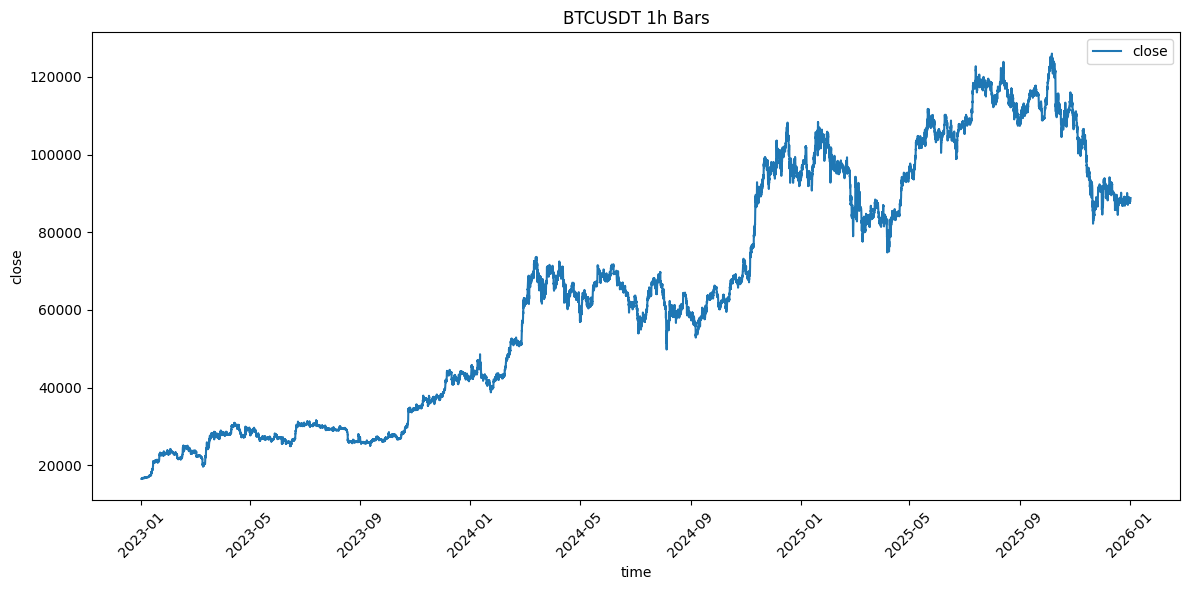

In [8]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [9]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [10]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [11]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [12]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16540.9,16504.0,16527.0,null
2023-01-01 01:00:00,16527.1,16554.3,16524.1,16550.4,0.001415
2023-01-01 02:00:00,16550.5,16557.1,16534.8,16542.4,-0.000483
2023-01-01 03:00:00,16542.5,16542.5,16515.0,16529.3,-0.000792
2023-01-01 04:00:00,16529.2,16530.4,16508.8,16517.8,-0.000696
…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,0.002147
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,-0.001522
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,0.001433


In [13]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16540.9,16504.0,16527.0,null,null,null,null,null
2023-01-01 01:00:00,16527.1,16554.3,16524.1,16550.4,0.001415,null,null,null,null
2023-01-01 02:00:00,16550.5,16557.1,16534.8,16542.4,-0.000483,0.001415,null,null,null
2023-01-01 03:00:00,16542.5,16542.5,16515.0,16529.3,-0.000792,-0.000483,0.001415,null,null
2023-01-01 04:00:00,16529.2,16530.4,16508.8,16517.8,-0.000696,-0.000792,-0.000483,0.001415,null
…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,0.002147,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,-0.001522,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,0.001433,-0.001522,0.002147,-0.001315,0.003703


In [14]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16540.9,16504.0,16527.0,null,null,null,null,null
2023-01-01 01:00:00,16527.1,16554.3,16524.1,16550.4,0.001415,null,null,null,null
2023-01-01 02:00:00,16550.5,16557.1,16534.8,16542.4,-0.000483,0.001415,null,null,null
2023-01-01 03:00:00,16542.5,16542.5,16515.0,16529.3,-0.000792,-0.000483,0.001415,null,null
2023-01-01 04:00:00,16529.2,16530.4,16508.8,16517.8,-0.000696,-0.000792,-0.000483,0.001415,null
…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,0.002147,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,-0.001522,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,0.001433,-0.001522,0.002147,-0.001315,0.003703


In [15]:
ts = ts.drop_nulls()

In [16]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [17]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [18]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [19]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

In [20]:
# y = w * x + b

### Split by time

In [21]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [22]:
len(ts)

26314

In [23]:
int(len(ts) * test_size)

6578

In [24]:
split_idx = int(len(ts) * (1-test_size))
split_idx

19735

In [25]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [26]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-01 05:00:00,16517.8,16531.1,16508.0,16525.7,0.000478,-0.000696,-0.000792,-0.000483,0.001415
2023-01-01 06:00:00,16525.6,16545.7,16525.6,16535.3,0.000581,0.000478,-0.000696,-0.000792,-0.000483
2023-01-01 07:00:00,16535.3,16537.5,16488.0,16519.6,-0.00095,0.000581,0.000478,-0.000696,-0.000792
2023-01-01 08:00:00,16519.5,16524.9,16502.0,16504.2,-0.000933,-0.00095,0.000581,0.000478,-0.000696
2023-01-01 09:00:00,16504.3,16536.1,16496.8,16532.7,0.001725,-0.000933,-0.00095,0.000581,0.000478
…,…,…,…,…,…,…,…,…,…
2025-04-02 16:00:00,86709.5,87182.1,86534.7,87013.1,0.003495,0.010253,0.007497,0.002053,0.005673
2025-04-02 17:00:00,87013.0,87255.0,86303.7,86567.6,-0.005133,0.003495,0.010253,0.007497,0.002053
2025-04-02 18:00:00,86567.5,86691.8,86168.0,86245.6,-0.003727,-0.005133,0.003495,0.010253,0.007497


In [27]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-04-02 21:00:00,85623.2,85717.8,84184.1,84812.7,-0.009504,-0.014282,0.007032,-0.003727,-0.005133
2025-04-02 22:00:00,84812.8,84812.8,82635.3,82784.3,-0.024207,-0.009504,-0.014282,0.007032,-0.003727
2025-04-02 23:00:00,82784.2,82830.0,82300.0,82485.1,-0.003621,-0.024207,-0.009504,-0.014282,0.007032
2025-04-03 00:00:00,82485.1,83365.1,82137.3,83181.9,0.008412,-0.003621,-0.024207,-0.009504,-0.014282
2025-04-03 01:00:00,83182.0,83889.2,83050.0,83712.0,0.006353,0.008412,-0.003621,-0.024207,-0.009504
…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,0.002147,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,-0.001522,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,0.001433,-0.001522,0.002147,-0.001315,0.003703


In [28]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)

In [29]:
X_train

tensor([[-0.0007],
        [ 0.0005],
        [ 0.0006],
        ...,
        [-0.0051],
        [-0.0037],
        [ 0.0070]])

In [30]:
X_train.shape

torch.Size([19735, 1])

In [31]:
y_train

tensor([ 0.0005,  0.0006, -0.0009,  ..., -0.0037,  0.0070, -0.0143])

In [32]:
y_train.shape

torch.Size([19735])

In [33]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[ 0.0005],
        [ 0.0006],
        [-0.0009],
        ...,
        [-0.0037],
        [ 0.0070],
        [-0.0143]])

In [34]:
y_train.shape

torch.Size([19735, 1])

In [35]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[-0.0095],
        [-0.0242],
        [-0.0036],
        ...,
        [ 0.0014],
        [ 0.0029],
        [ 0.0022]])

In [36]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[-0.0007],
         [ 0.0005],
         [ 0.0006],
         ...,
         [-0.0051],
         [-0.0037],
         [ 0.0070]]),
 tensor([[-0.0143],
         [-0.0095],
         [-0.0242],
         ...,
         [-0.0015],
         [ 0.0014],
         [ 0.0029]]),
 tensor([[ 0.0005],
         [ 0.0006],
         [-0.0009],
         ...,
         [-0.0037],
         [ 0.0070],
         [-0.0143]]),
 tensor([[-0.0095],
         [-0.0242],
         [-0.0036],
         ...,
         [ 0.0014],
         [ 0.0029],
         [ 0.0022]]))

### Batch Gradient Descent

In [37]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# loss function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")
    


Training model...
Epoch [500/5000], Loss: 0.468820
Epoch [1000/5000], Loss: 0.234593
Epoch [1500/5000], Loss: 0.101728
Epoch [2000/5000], Loss: 0.036155
Epoch [2500/5000], Loss: 0.009765
Epoch [3000/5000], Loss: 0.001831
Epoch [3500/5000], Loss: 0.000231
Epoch [4000/5000], Loss: 0.000040
Epoch [4500/5000], Loss: 0.000028
Epoch [5000/5000], Loss: 0.000027

Learned parameters
linear.weight:
[[-0.06914839]]
linear.bias:
[0.00013855]

Test Loss: 0.000018, Train Loss: 0.000027


### Test Trading Peformance

In [38]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
0.001126,-0.009504,false,1.0,-0.009504,-0.009504
0.000796,-0.024207,false,1.0,-0.024207,-0.033711
0.001812,-0.003621,false,1.0,-0.003621,-0.037332
0.000389,0.008412,true,1.0,0.008412,-0.028919
-0.000443,0.006353,false,-1.0,-0.006353,-0.035272
…,…,…,…,…,…
0.000229,0.002147,true,1.0,0.002147,0.062287
-0.00001,-0.001522,true,-1.0,0.001522,0.063809
0.000244,0.001433,true,1.0,0.001433,0.065242


In [39]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [40]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
0.001126,-0.009504,false,1.0,-0.009504,-0.009504,0.0
0.000796,-0.024207,false,1.0,-0.024207,-0.033711,-0.024207
0.001812,-0.003621,false,1.0,-0.003621,-0.037332,-0.027828
0.000389,0.008412,true,1.0,0.008412,-0.028919,-0.019416
-0.000443,0.006353,false,-1.0,-0.006353,-0.035272,-0.025768
…,…,…,…,…,…,…
0.000229,0.002147,true,1.0,0.002147,0.062287,-0.270812
-0.00001,-0.001522,true,-1.0,0.001522,0.063809,-0.26929
0.000244,0.001433,true,1.0,0.001433,0.065242,-0.267857


In [41]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.30864548683166504

In [42]:
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.2655589070816038)

In [43]:
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-265.55890708160376)

In [44]:
win_rate = trade_results['is_won'].mean()
win_rate

0.5063079495364037

In [45]:
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev

1.0020877750975543e-05

In [46]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return

0.06592738628387451

In [47]:
compound_return = np.exp(total_log_return)
compound_return

np.float64(1.0681491520705744)

In [48]:
1000*compound_return

np.float64(1068.1491520705745)

In [49]:
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.1636071503162384

In [50]:
equity_peak = trade_results['equity_curve'].max()
equity_peak

0.33309897780418396

In [51]:
std = trade_results['trade_log_return'].std()
std

0.00424785353243351

In [52]:
sharpe = ev / std * annualized_rate
sharpe

np.float64(0.2207945165259711)

In [53]:
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 6579,
 'win_rate': 0.5063079495364037,
 'avg_win': 0.0027671812094407964,
 'avg_loss': -0.0028175964451735295,
 'best_trade': 0.03395244851708412,
 'worst_trade': -0.049065329134464264,
 'ev': 1.0020877750975543e-05,
 'std': 0.00424785353243351,
 'total_log_return': 0.06592738628387451,
 'compound_return': np.float64(1.0681491520705744),
 'max_drawdown': -0.30864548683166504,
 'equity_trough': -0.1636071503162384,
 'equity_peak': 0.33309897780418396,
 'sharpe': np.float64(0.22079451652597545)}

In [54]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 6579,
 'win_rate': 0.5132998936008512,
 'avg_win': 0.002747918702074194,
 'avg_loss': -0.0028386359792836858,
 'best_trade': 0.03395244851708412,
 'worst_trade': -0.049065329134464264,
 'ev': 2.894194425265089e-05,
 'std': 0.004247766453772783,
 'total_log_return': 0.19040906429290771,
 'compound_return': np.float64(1.2097443596767048),
 'max_drawdown': -0.2612016201019287,
 'equity_trough': -0.2106088548898697,
 'equity_peak': 0.3740098476409912,
 'sharpe': np.float64(0.6377039762506713),
 'weights': '[-0.02553039]',
 'biases': '7.834147254470736e-05'}

In [55]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:    
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, test_size=test_size, no_epochs=200, loss=nn.L1Loss()))

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",6579,0.512692,0.002746,-0.002841,0.033952,-0.049065,0.000023,0.004248,0.153758,1.166209,-0.273102,-0.210619,0.349259,0.514951,"""[-0.02553547]""","""7.694992382312194e-05"""
"""close_log_return_lag_1""","""close_log_return""",6579,0.506004,0.002763,-0.002822,0.033952,-0.049065,0.000004,0.004248,0.028236,1.028639,-0.386158,-0.149217,0.236941,0.094565,"""[-0.09804779]""","""9.027872874867171e-05"""
"""close_log_return_lag_3""","""close_log_return""",6579,0.49734,0.002811,-0.002774,0.049065,-0.037794,0.000004,0.004248,0.023696,1.023979,-0.491734,-0.080063,0.440533,0.079358,"""[-0.01506131]""","""8.119879203150049e-05"""
"""close_log_return_lag_4""","""close_log_return""",6579,0.50114,0.002765,-0.002819,0.033952,-0.049065,-0.000021,0.004248,-0.137442,0.871585,-0.448537,-0.327134,0.121402,-0.460306,"""[-0.01038077]""","""8.491501648677513e-05"""


In [56]:
research.auto_reg_corr_matrx(ts, target, max_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.021029,0.006928,-0.002763,0.010927
-0.021029,1.0,-0.021038,0.006924,-0.002759
0.006928,-0.021038,1.0,-0.021043,0.006929
-0.002763,0.006924,-0.021043,1.0,-0.021041
0.010927,-0.002759,0.006929,-0.021041,1.0


In [57]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

## Add Transaction Fees

In [58]:
maker_fee = 0.0001
taker_fee = 0.0003

roundtrip_fee_log = np.log(1 - 2 * taker_fee)

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col('trade_log_return') + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))

model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
-0.000101,-0.009504,true,-1.0,0.009504,0.009504,0.0,-0.0006,0.008904,0.008904
0.000441,-0.024207,false,1.0,-0.024207,-0.014703,-0.024207,-0.0006,-0.024807,-0.015903
0.000319,-0.003621,false,1.0,-0.003621,-0.018324,-0.027828,-0.0006,-0.004221,-0.020124
0.000693,0.008412,true,1.0,0.008412,-0.009912,-0.019416,-0.0006,0.007812,-0.012312
0.00017,0.006353,true,1.0,0.006353,-0.003559,-0.013063,-0.0006,0.005752,-0.00656
…,…,…,…,…,…,…,…,…,…
-0.000016,0.002147,false,-1.0,-0.002147,0.185383,-0.188626,-0.0006,-0.002747,-3.760801
0.000111,-0.001522,false,1.0,-0.001522,0.183861,-0.190149,-0.0006,-0.002122,-3.762924
0.000023,0.001433,true,1.0,0.001433,0.185294,-0.188716,-0.0006,0.000833,-3.762091


In [59]:
research.plot_column(model_trades, 'equity_curve_net')

alt.Chart(...)

In [60]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [61]:
model_trades['is_won'].mean()

0.5132998936008512

In [62]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
-0.000101,-0.009504,true,-1.0,0.009504,0.009504,0.0,-0.0006,0.008904,0.008904,-9.200836,-8.102224,-9.200836,-8.102224
0.000441,-0.024207,false,1.0,-0.024207,-0.014703,-0.024207,-0.0006,-0.024807,-0.015903,-9.234547,-8.135935,-18.435384,-16.238159
0.000319,-0.003621,false,1.0,-0.003621,-0.018324,-0.027828,-0.0006,-0.004221,-0.020124,-9.213961,-8.115349,-27.649345,-24.353508
0.000693,0.008412,true,1.0,0.008412,-0.009912,-0.019416,-0.0006,0.007812,-0.012312,-9.201928,-8.103316,-36.851273,-32.456824
0.00017,0.006353,true,1.0,0.006353,-0.003559,-0.013063,-0.0006,0.005752,-0.00656,-9.203988,-8.105376,-46.055261,-40.562199
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.000016,0.002147,false,-1.0,-0.002147,0.185383,-0.188626,-0.0006,-0.002747,-3.760801,-9.212487,-8.113875,-60557.802563,-53334.426765
0.000111,-0.001522,false,1.0,-0.001522,0.183861,-0.190149,-0.0006,-0.002122,-3.762924,-9.211863,-8.11325,-60567.014425,-53342.540015
0.000023,0.001433,true,1.0,0.001433,0.185294,-0.188716,-0.0006,0.000833,-3.762091,-9.208907,-8.110295,-60576.223333,-53350.65031


In [63]:
time_interval = '6h'
ts = research.load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts


Loading BTCUSDT: 100%|██████████| 1097/1097 [01:44<00:00, 10.48day/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16557.1,16504.0,16525.7
2023-01-01 06:00:00,16525.6,16549.8,16488.0,16549.8
2023-01-01 12:00:00,16549.8,16589.4,16524.6,16573.1
2023-01-01 18:00:00,16573.1,16618.8,16573.0,16610.3
2023-01-02 00:00:00,16610.4,16700.7,16541.2,16640.0
…,…,…,…,…
2025-12-31 18:00:00,87587.2,87952.0,87189.2,87608.2
2026-01-01 00:00:00,87608.3,88065.0,87508.4,87674.7
2026-01-01 06:00:00,87674.7,87985.6,87558.5,87980.1


In [64]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16557.1,16504.0,16525.7,null,null,null,null
2023-01-01 06:00:00,16525.6,16549.8,16488.0,16549.8,0.001457,null,null,null
2023-01-01 12:00:00,16549.8,16589.4,16524.6,16573.1,0.001407,0.001457,null,null
2023-01-01 18:00:00,16573.1,16618.8,16573.0,16610.3,0.002242,0.001407,0.001457,null
2023-01-02 00:00:00,16610.4,16700.7,16541.2,16640.0,0.001786,0.002242,0.001407,0.001457
…,…,…,…,…,…,…,…,…
2025-12-31 18:00:00,87587.2,87952.0,87189.2,87608.2,0.00024,-0.015637,0.006224,-0.000449
2026-01-01 00:00:00,87608.3,88065.0,87508.4,87674.7,0.000759,0.00024,-0.015637,0.006224
2026-01-01 06:00:00,87674.7,87985.6,87558.5,87980.1,0.003477,0.000759,0.00024,-0.015637


In [65]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006723,-0.007035,0.075276,-0.052576,0.000183,0.010296,0.200325,1.2218,-0.348483,-0.047353,0.466426,1.66152,"""[0.01502132]""","""0.0004840105539187789"""
"""close_log_return_lag_2""","""close_log_return""",1096,0.524635,0.006652,-0.007114,0.075276,-0.052576,0.000108,0.010297,0.118474,1.125777,-0.402371,-0.08373,0.413048,0.982536,"""[0.01448049]""","""0.00048348173731938004"""
"""close_log_return_lag_1""","""close_log_return""",1096,0.521898,0.006647,-0.007116,0.075276,-0.052576,0.000067,0.010297,0.073769,1.076558,-0.420077,-0.079202,0.417576,0.611765,"""[-0.00424116]""","""0.0004888940020464361"""


In [66]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.008259,0.010086,0.013598
-0.008259,1.0,-0.008282,0.010062
0.010086,-0.008282,1.0,-0.008295
0.013598,0.010062,-0.008295,1.0


In [67]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006698,-0.007063,0.075276,-0.052576,0.000157,0.010296,0.171685,1.187303,-0.344649,-0.047353,0.43395,1.423913,"""[0.01535778]""","""0.0004808625963050872"""
"""close_log_return_lag_2""","""close_log_return""",1096,0.524635,0.006652,-0.007114,0.075276,-0.052576,0.000108,0.010297,0.118474,1.125777,-0.402371,-0.08373,0.413048,0.982536,"""[0.0146959]""","""0.00048164676991291344"""
"""close_log_return_lag_1""","""close_log_return""",1096,0.521898,0.006647,-0.007116,0.075276,-0.052576,0.000067,0.010297,0.073769,1.076558,-0.420077,-0.079202,0.417576,0.611765,"""[-0.00389837]""","""0.000494202773552388"""


In [68]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss(), test_size=0.3)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",1316,0.525076,0.00705,-0.007695,0.088826,-0.057483,0.000047,0.011221,0.062409,1.064397,-0.285501,-0.19818,0.116899,0.395574,"""[-0.06776486]""","""0.0002637650177348405"""
"""close_log_return_lag_3""","""close_log_return""",1316,0.530395,0.006937,-0.00783,0.088826,-0.063243,0.000002,0.011221,0.002887,1.002891,-0.322037,-0.276692,0.180534,0.018296,"""[-0.01630509]""","""0.00018294596520718187"""
"""close_log_return_lag_2""","""close_log_return""",1316,0.525076,0.006924,-0.007835,0.088826,-0.063243,-0.000085,0.01122,-0.112373,0.893711,-0.42991,-0.245736,0.279312,-0.712283,"""[-0.0060417]""","""0.000198234265553765"""


In [69]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [70]:
research.plot_column(model_trades, 'equity_curve_net_taker')

alt.Chart(...)

## Research 12 forecast horizon

In [71]:
time_interval = '12h'


In [72]:
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-01 00:00:00,16537.5,16557.1,16504.0,16525.7,null,null,null,null,null
2023-01-01 06:00:00,16525.6,16549.8,16488.0,16549.8,0.001457,null,null,null,null
2023-01-01 12:00:00,16549.8,16589.4,16524.6,16573.1,0.001407,0.001457,null,null,null
2023-01-01 18:00:00,16573.1,16618.8,16573.0,16610.3,0.002242,0.001407,0.001457,null,null
2023-01-02 00:00:00,16610.4,16700.7,16541.2,16640.0,0.001786,0.002242,0.001407,0.001457,null
…,…,…,…,…,…,…,…,…,…
2025-12-31 18:00:00,87587.2,87952.0,87189.2,87608.2,0.00024,-0.015637,0.006224,-0.000449,0.001415
2026-01-01 00:00:00,87608.3,88065.0,87508.4,87674.7,0.000759,0.00024,-0.015637,0.006224,-0.000449
2026-01-01 06:00:00,87674.7,87985.6,87558.5,87980.1,0.003477,0.000759,0.00024,-0.015637,0.006224


In [73]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006774,-0.006979,0.075276,-0.052576,0.000236,0.010295,0.259038,1.295683,-0.295572,-0.050099,0.472228,2.14872,"""[-0.00595272 0.01651621]""","""0.00047395899309776723"""
"""close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006698,-0.007063,0.075276,-0.052576,0.000157,0.010296,0.171685,1.187303,-0.344649,-0.047353,0.43395,1.423913,"""[0.01535635]""","""0.00048045741277746856"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",1096,0.523723,0.006705,-0.007054,0.075276,-0.052576,0.000152,0.010297,0.166377,1.181019,-0.290792,-0.063651,0.357938,1.379887,"""[0.01437537 0.01474147]""","""0.0004647987079806626"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",1096,0.521898,0.006692,-0.007067,0.075276,-0.052576,0.000113,0.010297,0.124269,1.132321,-0.256613,-0.101618,0.279903,1.030604,"""[-0.00343913 0.01480966 0.01535806]""","""0.0004775858542416245"""
"""close_log_return_lag_2""","""close_log_return""",1096,0.524635,0.006652,-0.007114,0.075276,-0.052576,0.000108,0.010297,0.118474,1.125777,-0.402371,-0.08373,0.413048,0.982536,"""[0.01469426]""","""0.000481248163850978"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",1096,0.523723,0.00663,-0.007137,0.075276,-0.052576,0.000073,0.010297,0.080234,1.083541,-0.358495,-0.07322,0.330933,0.665386,"""[-0.00447077 0.0146718 ]""","""0.00047419252223335207"""
"""close_log_return_lag_1""","""close_log_return""",1096,0.521898,0.006647,-0.007116,0.075276,-0.052576,0.000067,0.010297,0.073769,1.076558,-0.420077,-0.079202,0.417576,0.611765,"""[-0.00361182]""","""0.0004913227749057114"""


In [74]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006774,-0.006979,0.075276,-0.052576,0.000236,0.010295,0.259038,1.295683,-0.295572,-0.050099,0.472228,2.14872,"""[-0.0058048 0.0166964]""","""0.00048813907778821886"""
"""close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006723,-0.007035,0.075276,-0.052576,0.000183,0.010296,0.200325,1.2218,-0.348483,-0.047353,0.466426,1.66152,"""[0.01501312]""","""0.00048367466661147773"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",1096,0.52281,0.006675,-0.007086,0.075276,-0.052576,0.000109,0.010297,0.119073,1.126453,-0.318832,-0.101618,0.338674,0.987508,"""[0.01453742 0.01491621]""","""0.0004788036458194256"""
"""close_log_return_lag_2""","""close_log_return""",1096,0.524635,0.006652,-0.007114,0.075276,-0.052576,0.000108,0.010297,0.118474,1.125777,-0.402371,-0.08373,0.413048,0.982536,"""[0.01447304]""","""0.00048314238665625453"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",1096,0.524635,0.006647,-0.007119,0.075276,-0.052576,0.000103,0.010297,0.113068,1.119708,-0.402371,-0.07322,0.407642,0.937698,"""[-0.00431055 0.01484998]""","""0.0004881557251792401"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",1096,0.523723,0.006654,-0.00711,0.075276,-0.052576,0.000099,0.010297,0.108389,1.114482,-0.40756,-0.079202,0.417576,0.898894,"""[-0.00406071 0.01012075 0.00485381]""","""0.0004916536854580045"""
"""close_log_return_lag_1""","""close_log_return""",1096,0.521898,0.006647,-0.007116,0.075276,-0.052576,0.000067,0.010297,0.073769,1.076558,-0.420077,-0.079202,0.417576,0.611765,"""[-0.00462674]""","""0.000488294695969671"""


In [75]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",1096,0.524635,0.006672,-0.007091,0.075276,-0.052576,0.00013,0.010297,0.141955,1.152525,-0.333665,-0.115447,0.218218,1.1773,"""[-0.05984775]""","""0.00027985431370325387"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",1096,0.525547,0.006649,-0.007117,0.075276,-0.052576,0.000118,0.010297,0.129116,1.137822,-0.346826,-0.189004,0.157821,1.070806,"""[-0.05973273 -0.0189654 ]""","""0.00027098783175460994"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",1096,0.524635,0.006659,-0.007105,0.075276,-0.049403,0.000116,0.010297,0.127089,1.135519,-0.331788,-0.144935,0.186853,1.053996,"""[-0.04885912 -0.03282471]""","""0.00028338845004327595"""
"""close_log_return_lag_3""","""close_log_return""",1096,0.530109,0.006581,-0.007199,0.075276,-0.049403,0.000106,0.010297,0.115995,1.12299,-0.344514,-0.114117,0.369272,0.961975,"""[-0.02306032]""","""0.00023322965716943145"""
"""close_log_return_lag_2""","""close_log_return""",1096,0.528285,0.006537,-0.007246,0.075276,-0.052576,0.000035,0.010298,0.038651,1.039408,-0.358677,-0.111243,0.309147,0.320527,"""[-0.01300766]""","""0.00022478897881228477"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",1096,0.519161,0.006628,-0.007134,0.075276,-0.052576,0.00001,0.010298,0.011304,1.011369,-0.402218,-0.28279,0.119428,0.093746,"""[-0.05845405 -0.01545185 -0.02005741]""","""0.0002742242068052292"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",1096,0.531022,0.006473,-0.007322,0.075276,-0.049403,0.000004,0.010298,0.003923,1.00393,-0.347451,-0.126421,0.246119,0.032529,"""[-0.01330352 -0.0248954 ]""","""0.00018028459453489631"""


### Save Best Model (Sharpe 10 Model)

In [76]:
features = ['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [77]:
torch.save(model.state_dict(), 'model_weights.pth')